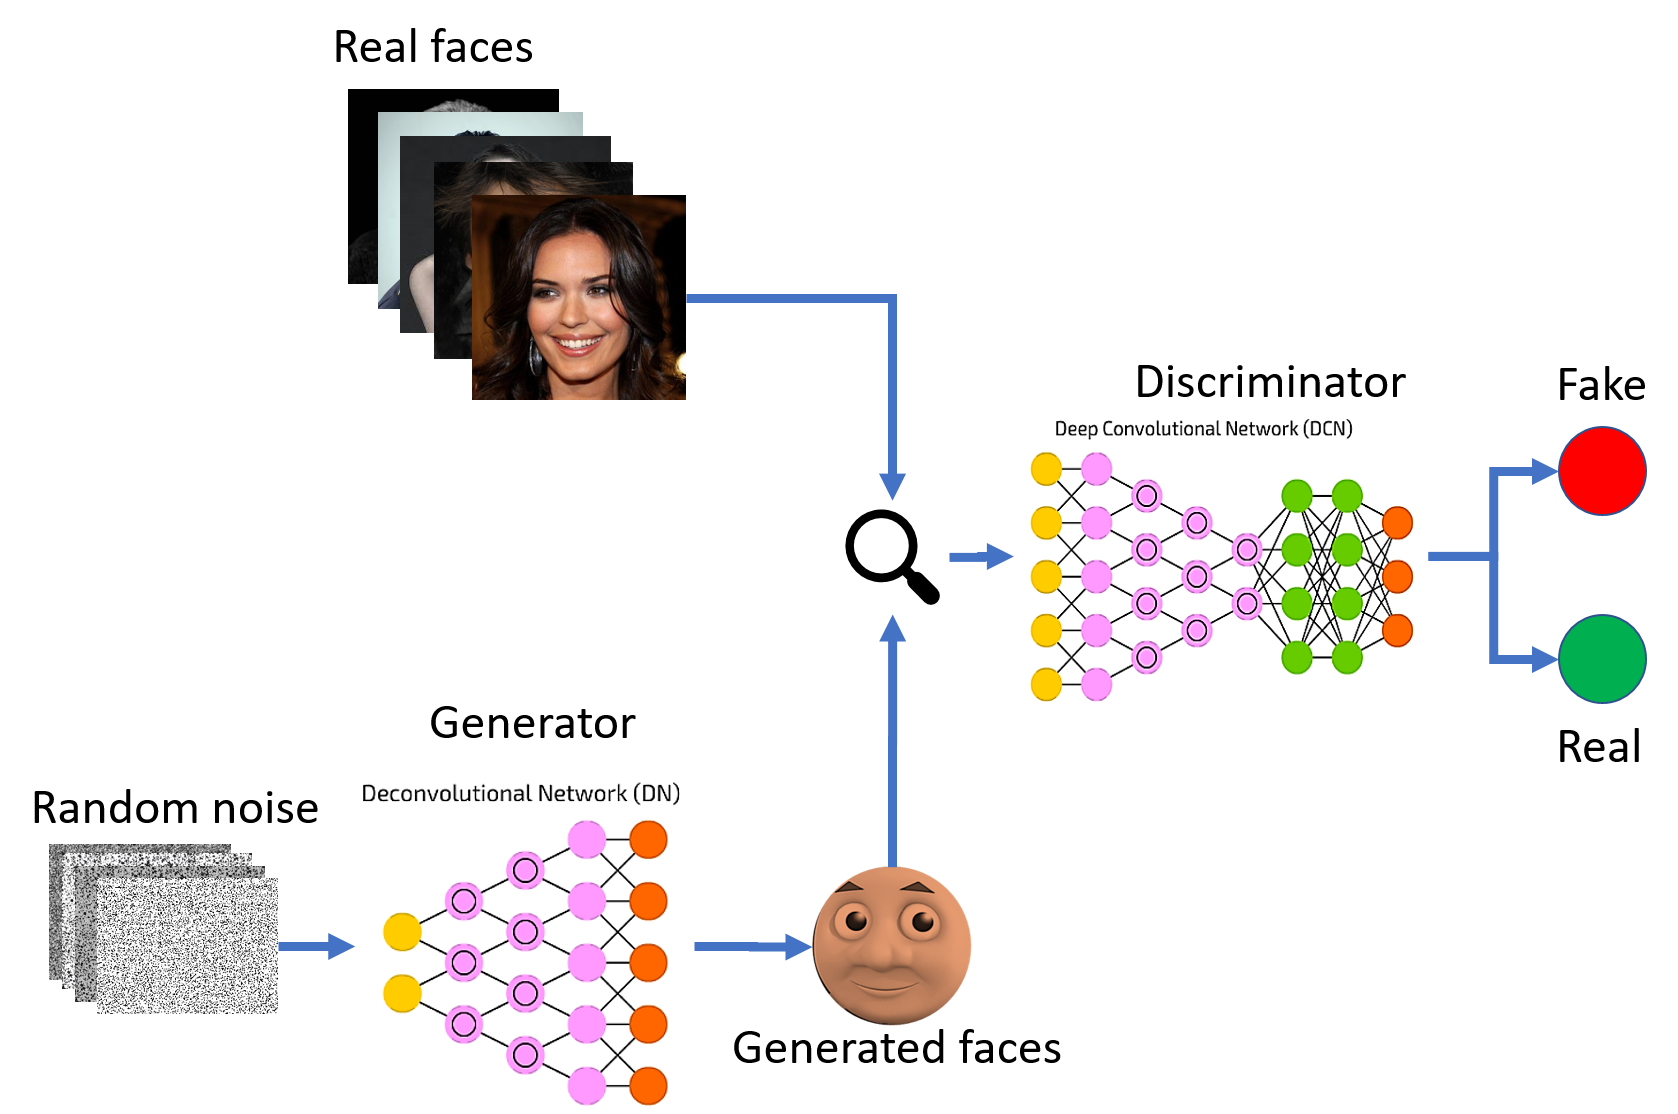

In [59]:
import keras
import  tensorflow as tf
from keras import layers
import matplotlib.pyplot as plt
from keras import ops
from keras import callbacks, utils, random
import os

In [50]:
directory = "me"
dataset=keras.utils.image_dataset_from_directory(
    directory,
    label_mode=None,
    color_mode="rgb",
    batch_size=3,
    image_size=(256, 256),
)

Found 43 files.


(256, 256, 3)
(256, 256, 3)
(256, 256, 3)


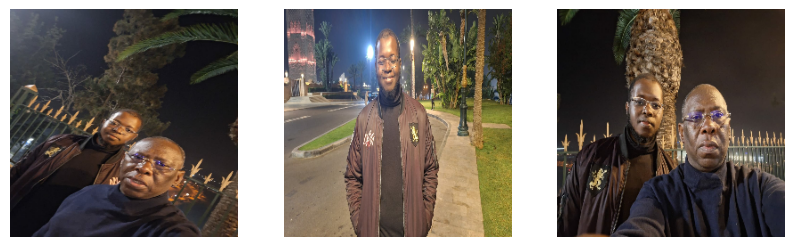

In [51]:
for image_batch in dataset:
    plt.figure(figsize=(10,10))
    for i in range(3):
        ax = plt.subplot(1,3,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")
        print( image_batch[i].numpy().astype("uint8").shape)
    break

## Generator

In [52]:
z_dim=256
input_size=16
""""
avec strides=2 a chaque couche deconv2dtranspose on double la taille de l'image
donc on a 4 couche alors 16(input_size)->32->64->128-> 256 (taille finale de l'image de notre dataset)
layers.Conv2D(3,kernel_size=3,padding="same",activation="sigmoid") sert a ramener le nombre de canaux a 3 (RGB)

"""
generator=keras.Sequential(
    [
        layers.Input(shape=(z_dim,)),
        layers.Dense(input_size*input_size*256),
        layers.Reshape((input_size,input_size,256)),
        layers.Conv2DTranspose(128,kernel_size=4,strides=2,padding="same",activation="relu"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(64,kernel_size=4,strides=2,padding="same",activation="relu"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(32,kernel_size=4,strides=2,padding="same",activation="relu"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(16,kernel_size=4,strides=2,padding="same",activation="relu"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(3,kernel_size=3,padding="same",activation="sigmoid"),

    ],name="generator"
)
generator.summary()

c:\Users\hp\Desktop\tous\ML\env\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 65536)          │    16,842,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 32, 32, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_33 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 64, 64, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_34 (LeakyReLU)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 128, 128, 32)   │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_35 (LeakyReLU)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 256, 256, 16)   │         8,208 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_36 (LeakyReLU)      │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 256, 256, 3)    │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,539,747 (66.91 MB)

 Trainable params: 17,539,747 (66.91 MB)

 Non-trainable params: 0 (0.00 B)

## Discriminator

In [54]:
""""
input shape = (256,256,3) car les images de notre dataset ont cette taille
on utilise des couches conv2d avec strides=2 pour reduire la taille de l'image

"""

descriminator = keras.Sequential(
    [
        layers.Input(shape=(256, 256, 3)),
        layers.Conv2D(64, kernel_size=(3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=(3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(256, kernel_size=(3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(512, kernel_size=(3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid")
    ],name="discriminator")
descriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_41 (LeakyReLU)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_42 (LeakyReLU)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_43 (LeakyReLU)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_44 (LeakyReLU)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │       131,073 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,682,049 (6.42 MB)

 Trainable params: 1,682,049 (6.42 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
class GAN(keras.Model):
    def __init__(self, discriminator, generator, z_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.z_dim = z_dim
        self.seed_generator = keras.random.SeedGenerator(1337)

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        # Sample random points in the z space
        batch_size = ops.shape(real_images)[0]
        random_z_vectors = keras.random.normal(
            shape=(batch_size, self.z_dim), seed=self.seed_generator
        )

        # Decode them to fake images
        generated_images = self.generator(random_z_vectors)

        # Combine them with real images
        combined_images = ops.concatenate([generated_images, real_images], axis=0)

        # Assemble labels discriminating real from fake images
        labels = ops.concatenate(
            [ops.ones((batch_size, 1)), ops.zeros((batch_size, 1))], axis=0
        )
        # Add random noise to the labels - important trick!
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        # Train the discriminator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # Sample random points in the z space
        random_z_vectors = keras.random.normal(
            shape=(batch_size, self.z_dim), seed=self.seed_generator
        )

        # Assemble labels that say "all real images"
        misleading_labels = ops.zeros((batch_size, 1))

        # Train the generator (note that we should *not* update the weights
        # of the discriminator)!
        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_z_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Update metrics
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }

In [60]:
class GANMonitor(callbacks.Callback):
    def __init__(self, output_dir="images_generated", num_img=3, z_dim=128):
        self.output_dir = output_dir
        self.num_img = num_img
        self.z_dim = z_dim
        self.seed_generator = random.SeedGenerator(42)

        # Crée le dossier automatiquement s’il n’existe pas
        os.makedirs(self.output_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        # Génération du bruit aléatoire
        random_z_vectors = random.normal(
            shape=(self.num_img, self.z_dim), seed=self.seed_generator
        )

        # Génération des images
        generated_images = self.model.generator(random_z_vectors)
        generated_images *= 255
        generated_images = generated_images.numpy()

        # Sauvegarde dans le dossier défini
        for i in range(self.num_img):
            img = utils.array_to_img(generated_images[i])
            file_path = os.path.join(
                self.output_dir, f"generated_img_epoch{epoch:03d}_{i}.png"
            )
            img.save(file_path)

In [62]:
gan=GAN(descriminator,generator,z_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss_fn=keras.losses.BinaryCrossentropy(),
)
gan.fit(
    dataset,
    epochs=100,
    callbacks=[GANMonitor(num_img=3, z_dim=z_dim)],
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 850ms/step - d_loss: 1.6406 - g_loss: 2.9635
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 815ms/step - d_loss: 0.3117 - g_loss: 3.9206
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 808ms/step - d_loss: 0.4508 - g_loss: 4.9058
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 811ms/step - d_loss: 0.8149 - g_loss: 5.9903
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 833ms/step - d_loss: 1.1964 - g_loss: 9.5411
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 828ms/step - d_loss: 1.6758 - g_loss: 14.0693
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 806ms/step - d_loss: 0.4586 - g_loss: 25.1995
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 832ms/step - d_loss: 0.6822 - g_loss: 16.6582
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 885ms/step - d_loss: 0.6763 - g_loss: 29.1092
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 848ms/step - d_loss: 0.9062 - g_loss: 41.1311
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 852ms/step - d_loss: 0.5435 - g_loss: 18.2092
Epoch 12/100
15/15 ━━━━━